In [1]:
# CELL 1: Configuration & imports
import os, sys, math, warnings
warnings.filterwarnings("ignore")
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# Optional libraries
try:
    import xgboost as xgb
except Exception:
    xgb = None

try:
    import shap
except Exception:
    shap = None

OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

print("Environment ready. OUTPUT_DIR:", OUTPUT_DIR)


Environment ready. OUTPUT_DIR: ./outputs


In [3]:
# CELL 2: Load the CSV and quick summary
INPUT_CSV = "Total Emissions Per Country (2000-2020).csv"
if not os.path.exists(INPUT_CSV):
    raise FileNotFoundError(f"CSV not found at {INPUT_CSV}. Upload the file to that path.")

df_raw = pd.read_csv(INPUT_CSV)
print("Raw shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
display(df_raw.head(6))


Raw shape: (58765, 25)
Columns: ['Area', 'Item', 'Element', 'Unit', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020']


,Area,Item,Element,Unit,2000,2001,2002,2003,2004,2005,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Afghanistan,Crop Residues,Direct emissions (N2O),kilotonnes,0.520,0.5267,0.8200,0.9988,0.8225,1.1821,...,1.0321,1.3726,1.4018,1.4584,1.2424,1.1940,1.0617,0.8988,1.2176,1.3170
1,Afghanistan,Crop Residues,Indirect emissions (N2O),kilotonnes,0.117,0.1185,0.1845,0.2247,0.1851,0.2660,...,0.2322,0.3088,0.3154,0.3281,0.2795,0.2687,0.2389,0.2022,0.2740,0.2963
2,Afghanistan,Crop Residues,Emissions (N2O),kilotonnes,0.637,0.6452,1.0045,1.2235,1.0075,1.4481,...,1.2643,1.6815,1.7173,1.7865,1.5220,1.4627,1.3005,1.1011,1.4916,1.6133
3,Afghanistan,Crop Residues,Emissions (CO2eq) from N2O (AR5),kilotonnes,168.807,170.9884,266.1975,324.2195,266.9995,383.7498,...,335.0379,445.5958,455.0727,473.4174,403.3181,387.6130,344.6447,291.7838,395.2689,427.5284
4,Afghanistan,Crop Residues,Emissions (CO2eq) (AR5),kilotonnes,168.807,170.9884,266.1975,324.2195,266.9995,383.7498,...,335.0379,445.5958,455.0727,473.4174,403.3181,387.6130,344.6447,291.7838,395.2689,427.5284
5,Afghanistan,Rice Cultivation,Emissions (CH4),kilotonnes,18.200,16.9400,18.9000,20.3000,27.3000,22.4000,...,29.4000,28.7000,28.7000,30.8000,22.9600,16.6600,15.3233,16.4555,17.8542,20.6577


In [5]:
# CELL 3: Convert wide (years as columns) -> long format (year, value)
# Assumes year columns are numeric-like column names such as '2000','2001',... '2020'
# Identify year columns automatically
non_year_cols = ["Area","Item","Element","Unit"]
# find columns that look like years (4-digit)
year_cols = [c for c in df_raw.columns if str(c).strip().isdigit()]
print("Detected year columns count:", len(year_cols))
if len(year_cols) == 0:
    # fallback: assume columns after 'Unit' are years
    start_idx = df_raw.columns.get_loc("Unit") + 1
    year_cols = list(df_raw.columns[start_idx:])

print("Year columns sample:", year_cols[:6])
# melt to long
df_long = df_raw.melt(id_vars=[c for c in df_raw.columns if c not in year_cols],
                      value_vars=year_cols,
                      var_name="year",
                      value_name="value")
# clean year and value types
df_long["year"] = df_long["year"].astype(int)
# coerce value to numeric
df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")
print("Long shape:", df_long.shape)
display(df_long.head(6))


Detected year columns count: 21
Year columns sample: ['2000', '2001', '2002', '2003', '2004', '2005']
Long shape: (1234065, 6)


,Area,Item,Element,Unit,year,value
0,Afghanistan,Crop Residues,Direct emissions (N2O),kilotonnes,2000,0.520
1,Afghanistan,Crop Residues,Indirect emissions (N2O),kilotonnes,2000,0.117
2,Afghanistan,Crop Residues,Emissions (N2O),kilotonnes,2000,0.637
3,Afghanistan,Crop Residues,Emissions (CO2eq) from N2O (AR5),kilotonnes,2000,168.807
4,Afghanistan,Crop Residues,Emissions (CO2eq) (AR5),kilotonnes,2000,168.807
5,Afghanistan,Rice Cultivation,Emissions (CH4),kilotonnes,2000,18.200


In [7]:
# CELL 4: Basic cleaning: drop rows with null Area/Item/Element, show missing fraction
df = df_long.dropna(subset=["Area","Item","Element"]).copy()
missing_values = df["value"].isna().mean()
print(f"Fraction of missing 'value': {missing_values:.3f}  (will impute later where needed)")
# quick counts
print("Unique Areas:", df["Area"].nunique(), "Unique Items:", df["Item"].nunique(), "Unique Elements:", df["Element"].nunique())
df.info()


Fraction of missing 'value': 0.076  (will impute later where needed)
Unique Areas: 280 Unique Items: 42 Unique Elements: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1234065 entries, 0 to 1234064
Data columns (total 6 columns):
 #   Column   Non-Null Count    Dtype  
---  ------   --------------    -----  
 0   Area     1234065 non-null  object 
 1   Item     1234065 non-null  object 
 2   Element  1234065 non-null  object 
 3   Unit     1234065 non-null  object 
 4   year     1234065 non-null  int32  
 5   value    1140515 non-null  float64
dtypes: float64(1), int32(1), object(4)
memory usage: 51.8+ MB


In [9]:
# CELL 5: Focus the analysis: choose a specific Element (e.g., 'Temperature change' or food emission element)
# Inspect unique 'Element' values to choose a target variable
elements = df["Element"].value_counts().index.tolist()
print("Top 10 Elements (by rows):", elements[:10])
# For ML, pick one element that is continuous and meaningful. If dataset is FAOSTAT-like, you might choose 'Temperature change' or 'Greenhouse gas emissions'
# We'll choose the most common Element by default:
target_element = elements[0]
print("Selected Element for modeling:", target_element)

# Filter df to that Element
df_elem = df[df["Element"] == target_element].copy().reset_index(drop=True)
print("Filtered shape:", df_elem.shape)
display(df_elem.head())


Top 10 Elements (by rows): ['Emissions (CO2eq) (AR5)', 'Emissions (N2O)', 'Emissions (CO2eq) from N2O (AR5)', 'Emissions (CH4)', 'Emissions (CO2eq) from CH4 (AR5)', 'Emissions (CO2)', 'Direct emissions (N2O)', 'Indirect emissions (N2O)', 'Emissions (CO2eq) from F-gases (AR5)']
Selected Element for modeling: Emissions (CO2eq) (AR5)
Filtered shape: (250446, 6)


,Area,Item,Element,Unit,year,value
0,Afghanistan,Crop Residues,Emissions (CO2eq) (AR5),kilotonnes,2000,168.8070
1,Afghanistan,Rice Cultivation,Emissions (CO2eq) (AR5),kilotonnes,2000,509.6000
2,Afghanistan,Burning - Crop residues,Emissions (CO2eq) (AR5),kilotonnes,2000,92.3047
3,Afghanistan,Burning - Crop residues,Emissions (CO2eq) (AR5),kilotonnes,2000,NaN
4,Afghanistan,Enteric Fermentation,Emissions (CO2eq) (AR5),kilotonnes,2000,7619.9200


In [11]:
# CELL 6 (fixed): Pivot or keep long - create per-(Area,Item) time series with lags
df_elem_sorted = df_elem.sort_values(["Area", "Item", "year"]).copy()

# Function to create lag features per group (robust implementation)
def create_lag_features(df_grouped, lags: List[int] = [1,2,3,5,10], rolling_windows: List[int] = [3,5]):
    dfg = df_grouped.copy()
    grp = dfg.groupby(["Area", "Item"])
    # initialize lag columns
    for lag in lags:
        dfg[f"lag_{lag}"] = grp["value"].shift(lag)
    # compute rolling means per group in a robust way
    for w in rolling_windows:
        colname = f"roll_mean_{w}"
        dfg[colname] = np.nan  # initialize
        # iterate groups and fill
        for (area, item), g in grp:
            idx = g.index
            # shift by 1 to exclude current year, then rolling mean
            rolled = g["value"].shift(1).rolling(window=w, min_periods=1).mean()
            dfg.loc[idx, colname] = rolled.values
    # add group size
    dfg["group_count"] = grp["value"].transform("count")
    return dfg

# Run it
df_features = create_lag_features(df_elem_sorted)
print("With lag features shape:", df_features.shape)
display(df_features.head(10))


With lag features shape: (250446, 14)


,Area,Item,Element,Unit,year,value,lag_1,lag_2,lag_3,lag_5,lag_10,roll_mean_3,roll_mean_5,group_count
44,Afghanistan,AFOLU,Emissions (CO2eq) (AR5),kilotonnes,2000,9160.8263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21
11970,Afghanistan,AFOLU,Emissions (CO2eq) (AR5),kilotonnes,2001,9858.4400,9160.8263,NaN,NaN,NaN,NaN,9160.826300,9160.826300,21
23896,Afghanistan,AFOLU,Emissions (CO2eq) (AR5),kilotonnes,2002,12262.5769,9858.4400,9160.8263,NaN,NaN,NaN,9509.633150,9509.633150,21
35822,Afghanistan,AFOLU,Emissions (CO2eq) (AR5),kilotonnes,2003,12639.7018,12262.5769,9858.4400,9160.8263,NaN,NaN,10427.281067,10427.281067,21
47748,Afghanistan,AFOLU,Emissions (CO2eq) (AR5),kilotonnes,2004,12513.3635,12639.7018,12262.5769,9858.4400,NaN,NaN,11586.906233,10980.386250,21
59674,Afghanistan,AFOLU,Emissions (CO2eq) (AR5),kilotonnes,2005,12817.6346,12513.3635,12639.7018,12262.5769,9160.8263,NaN,12471.880733,11286.981700,21
71600,Afghanistan,AFOLU,Emissions (CO2eq) (AR5),kilotonnes,2006,12837.8341,12817.6346,12513.3635,12639.7018,9858.4400,NaN,12656.899967,12018.343360,21
83526,Afghanistan,AFOLU,Emissions (CO2eq) (AR5),kilotonnes,2007,12930.6362,12837.8341,12817.6346,12513.3635,12262.5769,NaN,12722.944067,12614.222180,21
95452,Afghanistan,AFOLU,Emissions (CO2eq) (AR5),kilotonnes,2008,14299.6507,12930.6362,12837.8341,12817.6346,12639.7018,NaN,12862.034967,12747.834040,21
107378,Afghanistan,AFOLU,Emissions (CO2eq) (AR5),kilotonnes,2009,14750.2214,14299.6507,12930.6362,12837.8341,12513.3635,NaN,13356.040333,13079.823820,21


In [13]:
# CELL 7: Impute missing lag features (use median per Item where possible)
num_cols = [c for c in df_features.columns if c.startswith("lag_") or c.startswith("roll_")]
print("Lag/roll columns:", num_cols)

# Impute with group (Area+Item) median where available, else overall median
for col in num_cols:
    df_features[col] = df_features.groupby(["Area","Item"])[col].transform(lambda s: s.fillna(s.median()))
    df_features[col] = df_features[col].fillna(df_features[col].median())

# Drop rows where value is NaN (we cannot train on unknown targets)
before = len(df_features)
df_features = df_features.dropna(subset=["value"])
after = len(df_features)
print(f"Dropped {before-after} rows with missing target value.")


Lag/roll columns: ['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'roll_mean_3', 'roll_mean_5']
Dropped 22012 rows with missing target value.


In [14]:
df_features.shape

(228434, 14)

In [17]:
year_cols = [c for c in df_raw.columns if str(c).strip().isdigit()]
non_year_cols = [c for c in df_raw.columns if c not in year_cols]
df_long = df_raw.melt(id_vars=non_year_cols, value_vars=year_cols, var_name="Year", value_name="Emissions")
df_long["Year"] = df_long["Year"].astype(int)
df_long["Emissions"] = pd.to_numeric(df_long["Emissions"], errors="coerce")

print("Rows (long):", len(df_long))
print("Years:", sorted(df_long["Year"].unique())[:3], "...", sorted(df_long["Year"].unique())[-3:])
print("Areas:", df_long["Area"].nunique(), "Items:", df_long["Item"].nunique(), "Elements:", df_long["Element"].nunique())

Rows (long): 1234065
Years: [2000, 2001, 2002] ... [2018, 2019, 2020]
Areas: 280 Items: 42 Elements: 9


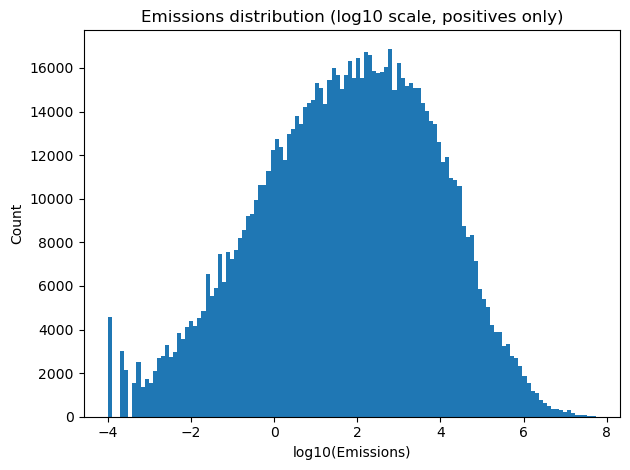

Inference: distribution is heavily right-skewed with a long tail; log-transform recommended for many analyses.


In [19]:
# CELL 2: Distribution — linear + log histograms (side-by-side)
vals = df_long["Emissions"].dropna()

# fig, axes = plt.subplots(1,2, figsize=(16,5))
# sns.histplot(vals, bins=120, ax=axes[0])
# axes[0].set_title("Emissions distribution (linear scale)")
# axes[0].set_xlabel("Emissions")
# axes[0].set_ylabel("Count")

# log10 histogram of positive values
pos = vals[vals > 0]
plt.hist(np.log10(pos), bins=120)
plt.title("Emissions distribution (log10 scale, positives only)")
plt.xlabel("log10(Emissions)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Inference
print("Inference: distribution is heavily right-skewed with a long tail; log-transform recommended for many analyses.")


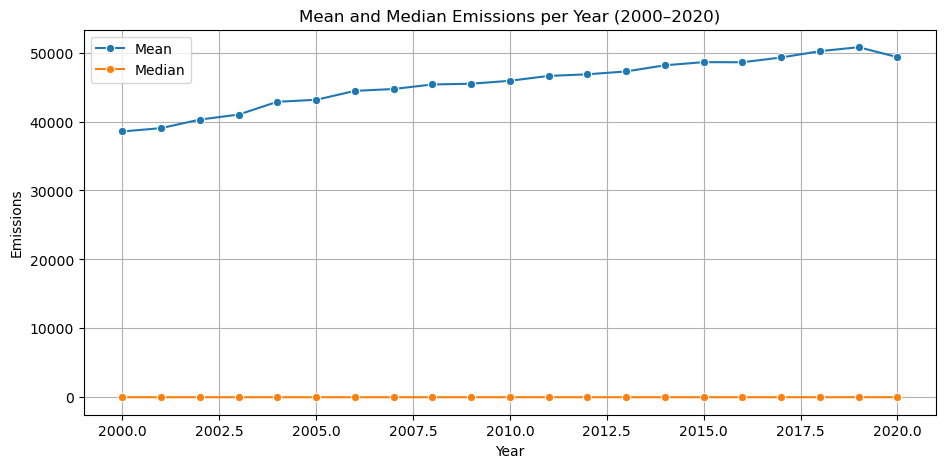

Inference: the mean gradually increases across years (driven by large values). Median is much lower than mean → skewness.


In [21]:
# CELL 3: Yearly trend — mean and median per year
year_stats = df_long.groupby("Year")["Emissions"].agg(["mean","median","count"]).reset_index()

plt.figure(figsize=(11,5))
sns.lineplot(data=year_stats, x="Year", y="mean", marker="o", label="Mean")
sns.lineplot(data=year_stats, x="Year", y="median", marker="o", label="Median")
plt.title("Mean and Median Emissions per Year (2000–2020)")
plt.ylabel("Emissions")
plt.grid(True)
plt.legend()
plt.show()

# Inference
print("Inference: the mean gradually increases across years (driven by large values). Median is much lower than mean → skewness.")


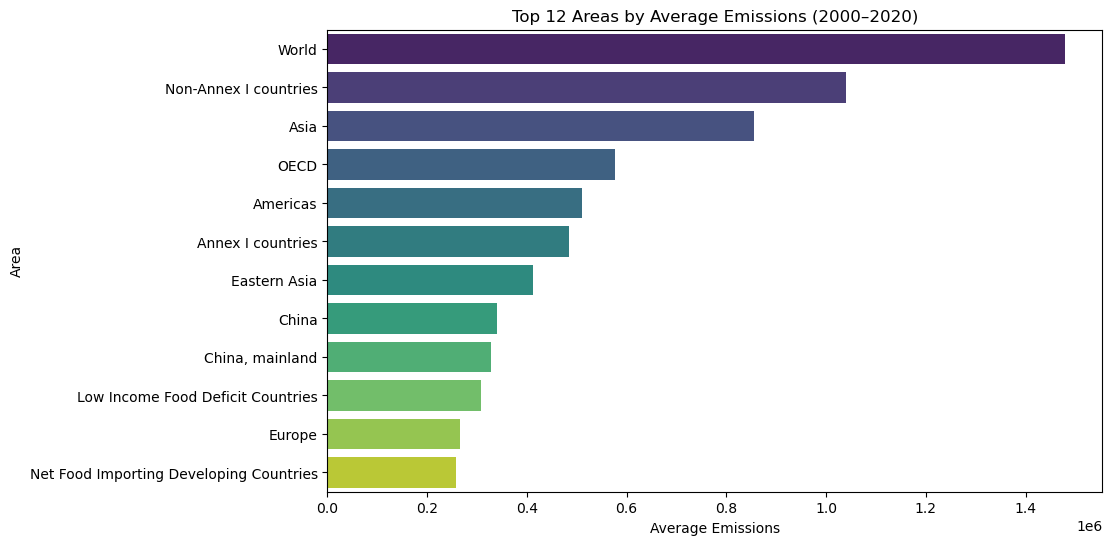

Inference: 'World' and aggregate regions often top the list — note aggregate rows vs country-level rows when modeling.


In [23]:
# CELL 5: Top 12 Areas by average emissions (horizontal bar)
top_n = 12
area_avg = df_long.groupby("Area")["Emissions"].mean().nlargest(top_n).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=area_avg, x="Emissions", y="Area", palette="viridis")
plt.title(f"Top {top_n} Areas by Average Emissions (2000–2020)")
plt.xlabel("Average Emissions")
plt.show()

# Inference
print("Inference: 'World' and aggregate regions often top the list — note aggregate rows vs country-level rows when modeling.")


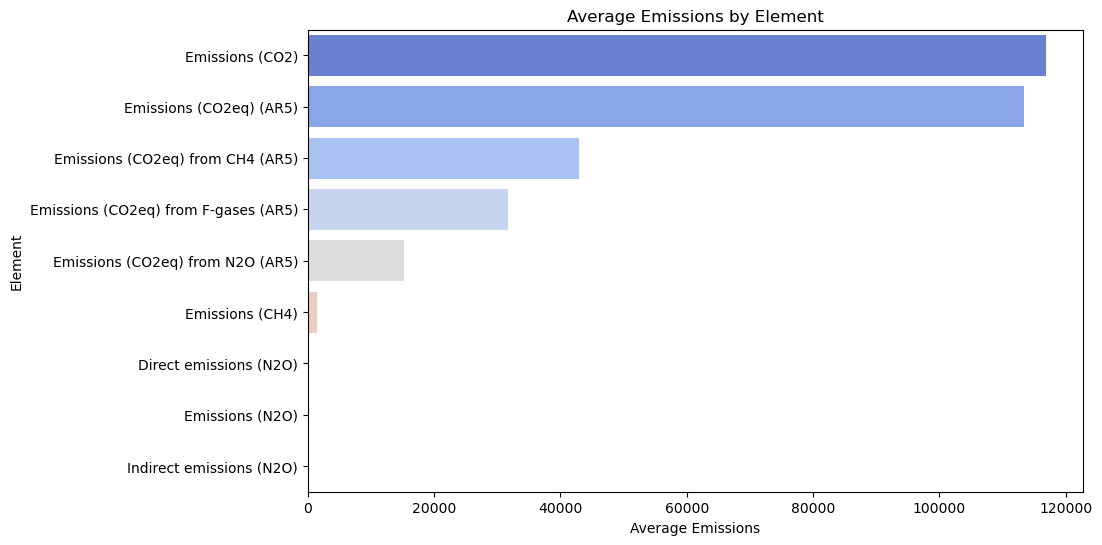

Inference: CO2/CO2eq types dominate average emissions. Consider modeling each Element separately if targets differ in scale.


In [25]:
# CELL 6: Average emissions by Element (category)
elem_avg = df_long.groupby("Element")["Emissions"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=elem_avg, x="Emissions", y="Element", palette="coolwarm")
plt.title("Average Emissions by Element")
plt.xlabel("Average Emissions")
plt.show()

# Inference
print("Inference: CO2/CO2eq types dominate average emissions. Consider modeling each Element separately if targets differ in scale.")


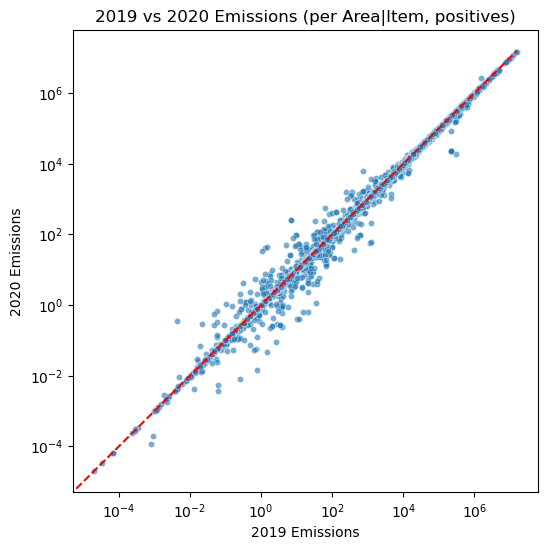

Inference: points cluster near diagonal — last year is a strong predictor for next year.


In [27]:
# CELL 8: 2019 vs 2020 scatter (autocorrelation / last-observation check)
pair = df_long[df_long["Year"].isin([2019,2020])]
pair_pivot = pair.pivot_table(index=["Area","Item"], columns="Year", values="Emissions")
if 2019 in pair_pivot.columns and 2020 in pair_pivot.columns:
    df_pair = pair_pivot[[2019,2020]].dropna().rename(columns={2019:"y2019", 2020:"y2020"})
    plt.figure(figsize=(6,6))
    sns.scatterplot(x="y2019", y="y2020", data=df_pair, alpha=0.6, s=20)
    mn = min(df_pair.min().min(), 1e-6)
    mx = df_pair.max().max()
    plt.plot([mn, mx], [mn, mx], "r--")
    plt.xscale("log"); plt.yscale("log")
    plt.title("2019 vs 2020 Emissions (per Area|Item, positives)")
    plt.xlabel("2019 Emissions"); plt.ylabel("2020 Emissions")
    plt.show()
    print("Inference: points cluster near diagonal — last year is a strong predictor for next year.")
else:
    print("Not enough paired 2019/2020 data to plot.")


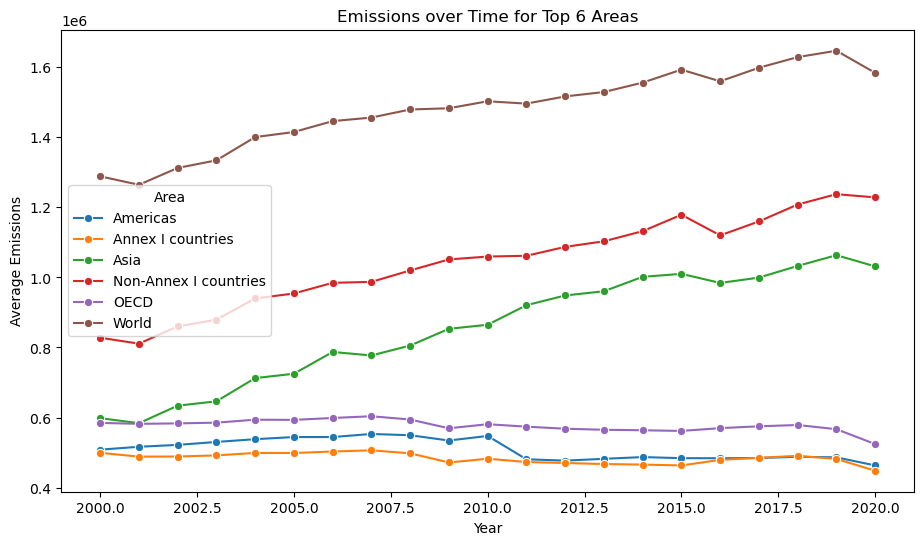

Inference: check whether top areas trend up/down; if trends differ, consider area-specific models or trend features.


In [29]:
# CELL 9: Top Areas time-series (multi-line for top 6)
top6 = area_avg["Area"].head(6).tolist()
ts = df_long[df_long["Area"].isin(top6)].groupby(["Year","Area"])["Emissions"].mean().reset_index()

plt.figure(figsize=(11,6))
sns.lineplot(data=ts, x="Year", y="Emissions", hue="Area", marker="o")
plt.title("Emissions over Time for Top 6 Areas")
plt.ylabel("Average Emissions")
plt.show()

# Inference
print("Inference: check whether top areas trend up/down; if trends differ, consider area-specific models or trend features.")


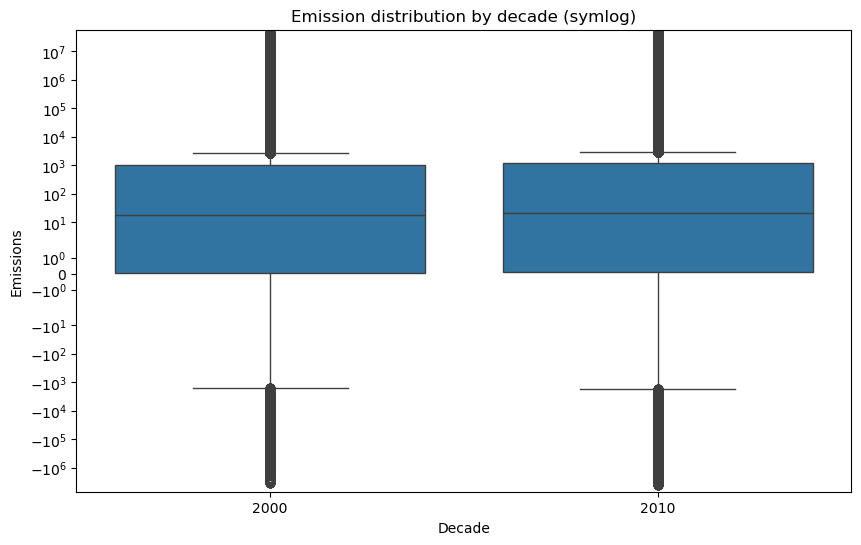

Inference: distributions have heavy tails in both decades; median changes (if visible) reflect central tendency shifts.


In [30]:
# CELL 10: Boxplot by decade (2000s vs 2010s) using symmetric log scale
df_long["Decade"] = (df_long["Year"] // 10) * 10
df_box = df_long[df_long["Decade"].isin([2000,2010])]

plt.figure(figsize=(10,6))
sns.boxplot(data=df_box, x="Decade", y="Emissions")
plt.yscale("symlog")   # helps with heavy tails and zeros
plt.title("Emission distribution by decade (symlog)")
plt.show()

# Inference
print("Inference: distributions have heavy tails in both decades; median changes (if visible) reflect central tendency shifts.")


✅ Correlation Matrix:



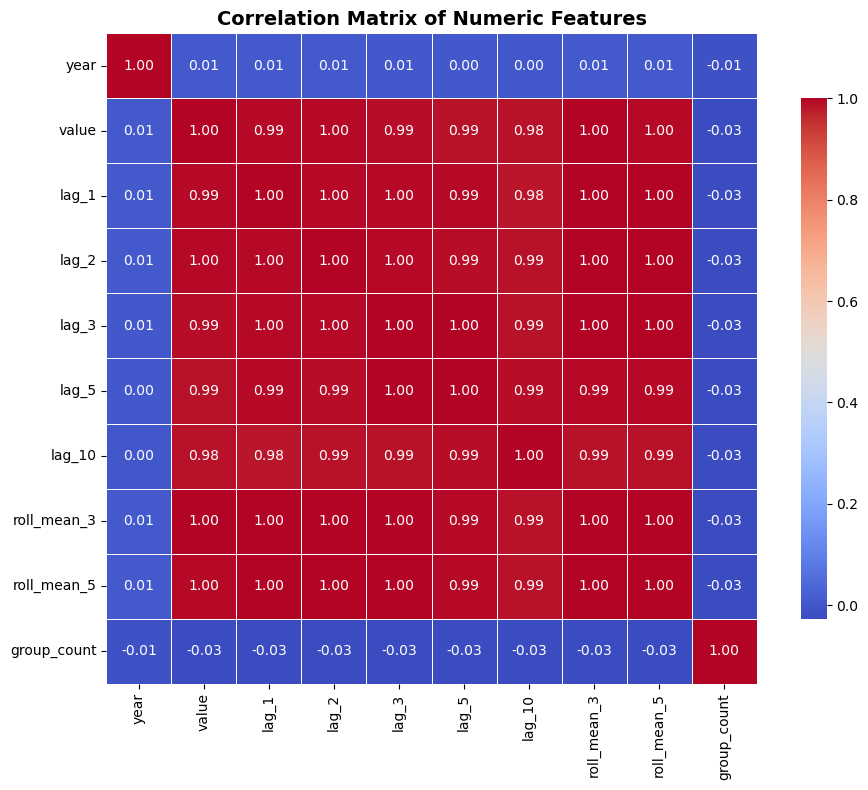

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    'year', 'value', 'lag_1', 'lag_2', 'lag_3',
    'lag_5', 'lag_10', 'roll_mean_3', 'roll_mean_5', 'group_count'
]

existing_cols = [col for col in numeric_cols if col in df_features.columns]
corr_matrix = df_features[existing_cols].corr()
print("✅ Correlation Matrix:\n")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)
plt.title("Correlation Matrix of Numeric Features", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


In [35]:
# CELL 8: Create additional categorical encodings and useful features
# Extract year as numeric is already present. Add decade or is_recent flag
df_features["is_recent"] = (df_features["year"] >= (df_features["year"].max() - 5)).astype(int)
# One-hot encode Area only if small; else use target encoding (here we'll label encode)
# We'll label-encode Area and Item to keep dimensionality small
df_features["area_code"] = df_features["Area"].astype("category").cat.codes
df_features["item_code"] = df_features["Item"].astype("category").cat.codes

# Keep a compact feature set
feature_cols = num_cols + ["year","is_recent","area_code","item_code","group_count"]
print("Final feature columns:", feature_cols)
display(df_features[feature_cols + ["value"]].head())


Final feature columns: ['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'roll_mean_3', 'roll_mean_5', 'year', 'is_recent', 'area_code', 'item_code', 'group_count']


,lag_1,lag_2,lag_3,lag_5,lag_10,roll_mean_3,roll_mean_5,year,is_recent,area_code,item_code,group_count,value
44,15070.6325,14750.2214,14524.93605,13615.14345,12817.6346,14641.522467,13927.307380,2000,0,0,0,21,9160.8263
11970,9160.8263,14750.2214,14524.93605,13615.14345,12817.6346,9160.826300,9160.826300,2001,0,0,0,21,9858.4400
23896,9858.4400,9160.8263,14524.93605,13615.14345,12817.6346,9509.633150,9509.633150,2002,0,0,0,21,12262.5769
35822,12262.5769,9858.4400,9160.82630,13615.14345,12817.6346,10427.281067,10427.281067,2003,0,0,0,21,12639.7018
47748,12639.7018,12262.5769,9858.44000,13615.14345,12817.6346,11586.906233,10980.386250,2004,0,0,0,21,12513.3635


In [37]:
df_features.columns.tolist()

['Area',
 'Item',
 'Element',
 'Unit',
 'year',
 'value',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_5',
 'lag_10',
 'roll_mean_3',
 'roll_mean_5',
 'group_count',
 'is_recent',
 'area_code',
 'item_code']

In [39]:
# CELL 9: Train/test split by time: use all years except the last year as train, last year as test
max_year = df_features["year"].max()
train_df = df_features[df_features["year"] < max_year].copy()
test_df = df_features[df_features["year"] == max_year].copy()
print("Train shape:", train_df.shape, "Test shape:", test_df.shape)

X_train = train_df[feature_cols]
y_train = train_df["value"]
X_test = test_df[feature_cols]
y_test = test_df["value"]

# quick scale numeric features (we'll scale only numeric lags/rolls/year/group_count)
num_to_scale = [c for c in feature_cols if c not in ["area_code","item_code","is_recent"]]
scaler = StandardScaler()
X_train[num_to_scale] = scaler.fit_transform(X_train[num_to_scale].fillna(0))
X_test[num_to_scale] = scaler.transform(X_test[num_to_scale].fillna(0))


Train shape: (217733, 17) Test shape: (10701, 17)


In [41]:
# CELL: Evaluate requested models (RF, HGB, XGB, LGBM, CatBoost, Linear)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold, cross_validate
import time

# optional libraries
try:
    import xgboost as xgb
except Exception:
    xgb = None
try:
    import lightgbm as lgb
except Exception:
    lgb = None
try:
    import catboost as cb
except Exception:
    cb = None

# helper
def rmse_np(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scoring = {
    "neg_root_mean_squared_error": "neg_root_mean_squared_error",
    "neg_mean_absolute_error": "neg_mean_absolute_error",
    "r2": "r2"
}

# Build models dictionary - keep n_jobs=1 for CV (avoid nested parallelism)
models = {}
models["RF"] = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=1)
models["HGB"] = HistGradientBoostingRegressor(max_iter=300, max_depth=12, random_state=RANDOM_STATE)

# XGBoost (if available)
if xgb is not None:
    try:
        models["XGB"] = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=8,
                                         subsample=0.8, colsample_bytree=0.8,
                                         random_state=RANDOM_STATE, n_jobs=1, verbosity=0)
    except Exception as e:
        print("Failed to create XGBRegressor:", e)

# LightGBM (if available)
if lgb is not None:
    try:
        models["LGBM"] = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=-1,
                                           subsample=0.8, colsample_bytree=0.8,
                                           random_state=RANDOM_STATE, n_jobs=1)
    except Exception as e:
        print("Failed to create LGBMRegressor:", e)

# CatBoost (if available)
if cb is not None:
    try:
        models["CatBoost"] = cb.CatBoostRegressor(iterations=300, learning_rate=0.05, depth=8,
                                                  random_seed=RANDOM_STATE, verbose=0, thread_count=1)
    except Exception as e:
        print("Failed to create CatBoostRegressor:", e)

# Linear baseline
models["Linear"] = LinearRegression()

# Prepare groups for GroupKFold (train only)
gkf = GroupKFold(n_splits=5)
groups = train_df["Area"].astype(str) + "||" + train_df["Item"].astype(str)

cv_summary_rows = []
test_summary_rows = []

for name, model in models.items():
    print("\n" + "="*80)
    print(f"Running CV for: {name}")
    t0 = time.time()
    try:
        cv_res = cross_validate(
            model,
            X_train.fillna(0),
            y_train,
            cv=gkf.split(X_train, y_train, groups=groups),
            scoring=scoring,
            n_jobs=-1,               # parallel across folds
            return_train_score=False,
            error_score="raise"
        )
    except Exception as e:
        print(f"Cross-validation failed for {name}: {e}")
        continue
    elapsed = time.time() - t0

    # convert negative scorers to positive values for RMSE/MAE
    rmse_vals = -1.0 * cv_res["test_neg_root_mean_squared_error"]
    mae_vals  = -1.0 * cv_res["test_neg_mean_absolute_error"]
    r2_vals   = cv_res["test_r2"]

    cv_row = {
        "model": name,
        "cv_rmse_mean": float(np.mean(rmse_vals)),
        "cv_rmse_std": float(np.std(rmse_vals, ddof=0)),
        "cv_mae_mean": float(np.mean(mae_vals)),
        "cv_mae_std": float(np.std(mae_vals, ddof=0)),
        "cv_r2_mean": float(np.mean(r2_vals)),
        "cv_r2_std": float(np.std(r2_vals, ddof=0)),
        "cv_time_sec": float(elapsed),
        "cv_folds": int(len(rmse_vals))
    }
    cv_summary_rows.append(cv_row)
    print("CV summary:", cv_row)

    # Fit on full train and evaluate on test set
    print(f"Fitting full {name} on train set and evaluating on test set...")
    # For final training you can enable multi-threading if you want (optional). Keep single-thread here to be safe.
    model.fit(X_train.fillna(0), y_train)
    y_test_pred = model.predict(X_test.fillna(0))
    test_rmse = rmse_np(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    test_row = {
        "model": name,
        "test_rmse": float(test_rmse),
        "test_mae": float(test_mae),
        "test_r2": float(test_r2),
        "trained_on_rows": int(len(X_train)),
        "tested_on_rows": int(len(X_test))
    }
    test_summary_rows.append(test_row)
    print("Test metrics:", test_row)

# Baselines
print("\n" + "="*80)
print("Computing baselines (global mean, last-observation per Area||Item) ...")
y_pred_mean = np.full(shape=len(y_test), fill_value=y_train.mean(), dtype=float)
baseline_mean = {
    "model": "BASE_mean",
    "test_rmse": float(rmse_np(y_test, y_pred_mean)),
    "test_mae": float(mean_absolute_error(y_test, y_pred_mean)),
    "test_r2": float(r2_score(y_test, y_pred_mean)),
    "trained_on_rows": int(len(X_train)),
    "tested_on_rows": int(len(X_test))
}
print("Baseline global-mean:", baseline_mean)
test_summary_rows.append(baseline_mean)

last_obs = train_df.sort_values("year").groupby(["Area","Item"])["value"].last()
def last_obs_pred(row):
    return last_obs.get((row["Area"], row["Item"]), y_train.mean())

y_pred_last = test_df.apply(lambda r: last_obs_pred(r), axis=1).values
baseline_last = {
    "model": "BASE_last_observation",
    "test_rmse": float(rmse_np(y_test, y_pred_last)),
    "test_mae": float(mean_absolute_error(y_test, y_pred_last)),
    "test_r2": float(r2_score(y_test, y_pred_last)),
    "trained_on_rows": int(len(X_train)),
    "tested_on_rows": int(len(X_test))
}
print("Baseline last-observation:", baseline_last)
test_summary_rows.append(baseline_last)

# Save results
cv_df = pd.DataFrame(cv_summary_rows).sort_values("cv_rmse_mean")
test_df_results = pd.DataFrame(test_summary_rows).sort_values("test_rmse")

cv_outpath = os.path.join(OUTPUT_DIR, "cv_results_models.csv")
test_outpath = os.path.join(OUTPUT_DIR, "test_results_models.csv")
cv_df.to_csv(cv_outpath, index=False)
test_df_results.to_csv(test_outpath, index=False)

print("\nSaved CV results to:", cv_outpath)
print("Saved Test results to:", test_outpath)
print("\nCV results:")
display(cv_df)
print("\nTest results:")
display(test_df_results)



Running CV for: RF
CV summary: {'model': 'RF', 'cv_rmse_mean': 78691.13369587024, 'cv_rmse_std': 11009.618953640991, 'cv_mae_mean': 7220.060974553507, 'cv_mae_std': 907.777308998585, 'cv_r2_mean': 0.993754282446166, 'cv_r2_std': 0.004212131455850423, 'cv_time_sec': 421.84946870803833, 'cv_folds': 5}
Fitting full RF on train set and evaluating on test set...
Test metrics: {'model': 'RF', 'test_rmse': 72672.32996415108, 'test_mae': 7084.034251074063, 'test_r2': 0.9966247724066439, 'trained_on_rows': 217733, 'tested_on_rows': 10701}

Running CV for: HGB
CV summary: {'model': 'HGB', 'cv_rmse_mean': 535418.640450213, 'cv_rmse_std': 105610.55227383166, 'cv_mae_mean': 30234.79364536114, 'cv_mae_std': 3701.7609256420133, 'cv_r2_mean': 0.7269917731246477, 'cv_r2_std': 0.15532935432161618, 'cv_time_sec': 9.927394390106201, 'cv_folds': 5}
Fitting full HGB on train set and evaluating on test set...
Test metrics: {'model': 'HGB', 'test_rmse': 85680.20560741035, 'test_mae': 9686.216374309612, 'test

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,cv_time_sec,cv_folds
0,RF,78691.133696,11009.618954,7220.060975,907.777309,0.993754,0.004212,421.849469,5
2,Linear,85953.958427,8425.164123,8595.518791,672.567286,0.993647,0.001573,2.470772,5
1,HGB,535418.640450,105610.552274,30234.793645,3701.760926,0.726992,0.155329,9.927394,5



Test results:


,model,test_rmse,test_mae,test_r2,trained_on_rows,tested_on_rows
0,RF,7.267233e+04,7084.034251,0.996625,217733,10701
2,Linear,8.007050e+04,9700.054185,0.995903,217733,10701
1,HGB,8.568021e+04,9686.216374,0.995308,217733,10701
4,BASE_last_observation,9.798783e+04,8493.081158,0.993864,217733,10701
3,BASE_mean,1.250929e+06,209484.227120,-0.000070,217733,10701


In [43]:
import joblib, os
OUTPUT_DIR = "./outputs"
for name, model in models.items():
    model_save_path = os.path.join(OUTPUT_DIR, f"{name}_model.joblib")
    joblib.dump(model, model_save_path)
    print(f"Saved: {model_save_path}")


Saved: ./outputs\RF_model.joblib
Saved: ./outputs\HGB_model.joblib
Saved: ./outputs\Linear_model.joblib


In [45]:
import os
print(os.listdir("./outputs"))


['best_model_Ridge.pkl', 'correlation_matrix.png', 'cv_results.csv', 'cv_results_full.csv', 'cv_results_models.csv', 'feature_list.csv', 'food_run_model_metrics.csv', 'HGB_model.joblib', 'Linear_model.joblib', 'model_metrics.csv', 'numeric_summary.csv', 'partial_dependence.png', 'pca_explained_variance.csv', 'permutation_importance.csv', 'pred_vs_actual.png', 'residuals_distribution.png', 'RF_model.joblib', 'scaler.pkl', 'scenario_transport50_predictions.csv', 'test_results_full.csv', 'test_results_models.csv']
